# Description
This notebook is a follow-up from `Data analysis with Biopython SW alignment`.  
In this notebook, I fit a logistic regression model to alignments of miRNAs and their targets to predict targeting.  
An alignment is represented as a vector of matches, dummy-encoded.   
I compare fits to all miRNAs and to individual miRNAs. Only 22nt miRNAs included.    
I compare models which encode types of matches and mismatches (AA, AT) and models which encode only match/mismatch/match-to-gap.  



**TODO**: correlate prediction score with SEG low complexity; Check reverse complements; Check two models for 5p and 3p  

In [1]:
from miRBench.dataset import list_datasets, get_dataset_df
from matplotlib import pyplot as plt
from sklearn.metrics import PrecisionRecallDisplay, average_precision_score
import numpy as np
import numpy.random as rd
from collections import Counter

In [2]:
from src.biopython_alignment import create_fresh_aligner, optimize_linear_gap, aligner_prc, score_aligner
from src.biopython_alignment import get_alignments, count_substitutions_per_miR_site

In [3]:
list_datasets()

['AGO2_CLASH_Hejret2023',
 'AGO2_eCLIP_Klimentova2022',
 'AGO2_eCLIP_Manakov2022']

In [4]:
dset = list_datasets()[0]
train = get_dataset_df(dset, split="train")
test = get_dataset_df(dset, split="test")
train.describe()

Using cached dataset /home/mciach/.miRBench/datasets/14501607/AGO2_CLASH_Hejret2023/train/dataset.tsv
Using cached dataset /home/mciach/.miRBench/datasets/14501607/AGO2_CLASH_Hejret2023/test/dataset.tsv


,label,start,end,gene_cluster_ID
count,8193.000000,8.193000e+03,8.193000e+03,8193.000000
mean,0.498474,6.824635e+07,6.824640e+07,2090.481753
std,0.500028,4.997466e+07,4.997466e+07,1240.486084
min,0.000000,3.306000e+03,3.355000e+03,1.000000
25%,0.000000,3.024620e+07,3.024624e+07,1015.000000
50%,0.000000,5.689580e+07,5.689585e+07,2094.000000
75%,1.000000,1.026173e+08,1.026173e+08,3174.000000
max,1.000000,2.416758e+08,2.416758e+08,4188.000000


In [5]:
train_len_select = [len(s)==22 for s in train['noncodingRNA']]
test_len_test = [len(s)==22 for s in test['noncodingRNA']]

In [6]:
train= train.loc[train_len_select]
test = test.loc[test_len_test]

In [7]:
miR_counter = Counter(train['noncodingRNA_name'])
sorted(miR_counter.items(), key = lambda x: x[1], reverse=True)[:14]

[('hsa-miR-92a-3p', 443),
 ('hsa-miR-744-5p', 435),
 ('hsa-miR-484', 395),
 ('hsa-miR-320a-3p', 385),
 ('hsa-miR-615-3p', 270),
 ('hsa-let-7a-5p', 245),
 ('hsa-let-7b-5p', 192),
 ('hsa-let-7e-5p', 183),
 ('hsa-miR-16-5p', 170),
 ('hsa-miR-193b-3p', 131),
 ('hsa-miR-125b-5p', 123),
 ('hsa-miR-324-5p', 120),
 ('hsa-miR-92b-3p', 117),
 ('hsa-miR-296-3p', 75)]

In [9]:
common_miR_names = [name for name in miR_counter if miR_counter[name] > 100]
len(common_miR_names)

13

# Getting alignments 

In [33]:
baseline_params = np.array([5, -4, -6])
baseline_aligner = create_fresh_aligner(*baseline_params)  # match, mismatch, gap

In [34]:
alignments_train = get_alignments(baseline_aligner, train)

In [35]:
alignments_test = get_alignments(baseline_aligner, test)

In [36]:
len(alignments_train)

4980

In [37]:
len(alignments_test)

568

# Fitting the simplest logistic model

We'll start with the simplest logistic model, which should work exactly the same as a local alignment score.  
We will fit a model to numbers of matches, mismatches and gaps in each alignment.    
This will simply be a logistic transformation of the alignment score.     

More details: a logistic score will have a form of 
$$\mathbb{P}(interaction) = \frac{1}{1+e^{\alpha -X\beta}}$$
where $X$ is a matrix of counts. Save for the intercept, $X\beta$ is just the alignment score.   

In [38]:
from src.logreg_analysis import encode_biopython_3features

In [39]:
simple_X_train = encode_biopython_3features(alignments_train)
simple_X_train.index = train.index

numpy done


In [68]:
from statsmodels.discrete.discrete_model import Logit

Fit the model:

In [41]:
logit_machine = Logit(endog = train['label'], exog=simple_X_train)
logit = logit_machine.fit()

Optimization terminated successfully.
         Current function value: 0.491317
         Iterations 6


In [42]:
logit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                  label   No. Observations:                 4980
Model:                          Logit   Df Residuals:                     4976
Method:                           MLE   Df Model:                            3
Date:                Mon, 13 Oct 2025   Pseudo R-squ.:                  0.2912
Time:                        11:30:09   Log-Likelihood:                -2446.8
converged:                       True   LL-Null:                       -3451.8
Covariance Type:            nonrobust   LLR p-value:                     0.000
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Match          0.7247      0.022     33.405      0.000       0.682       0.767
Mismatch      -0.6479      0.029    -22.409      0.000      -0.705      -0.591
Gap           -0.9013      0.038    -23.783      0.000      -0.976      -0.827
Intercept     -5.2263      0.163    -32.033      0.000      -5.546      -4.906
==============================================================================
"""

In [44]:
logit.params

Match        0.724709
Mismatch    -0.647892
Gap         -0.901264
Intercept   -5.226262
dtype: float64

Except for scaling, we get similar parameters. Scaling the logit parameters to the same Euclidean norm as the baseline algorithm parameters gives:

In [43]:
scaled_logit_params = logit.params[:3]*np.linalg.norm(baseline_params)/np.linalg.norm(logit.params[:3])
print(scaled_logit_params)
print(baseline_params)

Match       4.797259
Mismatch   -4.288761
Gap        -5.965973
dtype: float64
[ 5 -4 -6]


The fitted logit params are somewhat different than GSS fitted params - logit learns a different thing.

In [20]:
gss_params = [4.1240132136528445, -3.9816707148654795, -6.514813047510916]
scaled_logit_params = logit.params[:3]*np.linalg.norm(gss_params)/np.linalg.norm(logit.params[:3])
print(scaled_logit_params)
print(gss_params)

Match       4.744132
Mismatch   -4.241265
Gap        -5.899903
dtype: float64
[4.1240132136528445, -3.9816707148654795, -6.514813047510916]


We also get similar PRC curves to the baseline aligner:

In [21]:
simple_X_test = encode_biopython_3features(alignments_test)
simple_X_test.index = test.index

numpy done


Average precision: 0.8513685972603834


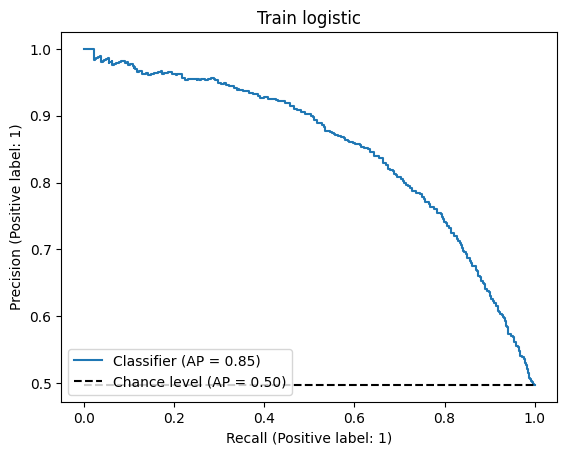

In [22]:
l, s = train['label'], logit.predict()
display = PrecisionRecallDisplay.from_predictions(
    l,
    s, 
    plot_chance_level=True, pos_label=1
)
_ = display.ax_.set_title('Train logistic')
print('Average precision:', average_precision_score(l, s))

Average precision: 0.8391594489235659


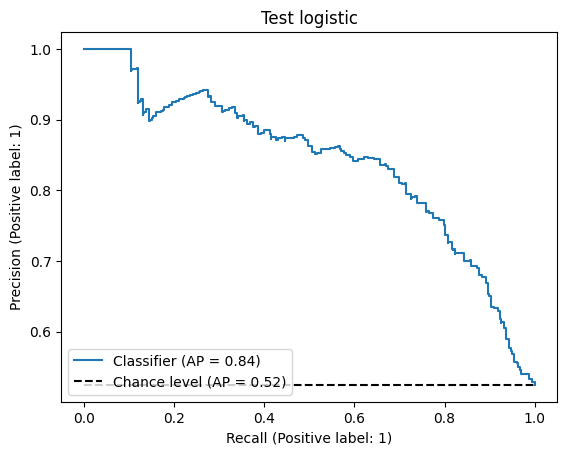

In [23]:
l, s = test['label'], logit.predict(simple_X_test)
display = PrecisionRecallDisplay.from_predictions(
    l,
    s, 
    plot_chance_level=True, pos_label=1
)
_ = display.ax_.set_title('Test logistic')
print('Average precision:', average_precision_score(l, s))

We get a small improvement of AUPRC, likely thanks to an additional flexibility of the intercept and re-scaling the parameters. 

# Simple position-aware model

We'll start with a simple position-aware model: dummy-encode whether a nucleotide is present in an alignment and whether it's a match (a hierarchical/nested model), and the numbers of gaps in the alignment.  
This should also somewhat reflect the alignment score: the coefficient for whether a nucleotide is in is a mismatch score, and whether it's a match is a correction.  


In [24]:
from src.logreg_analysis import encode_biopython_simple

Encode train alignments in a table:

In [25]:
X_train = encode_biopython_simple(alignments_train)
X_train.index = train.index

We will skip whether the trailing nucleotides are mismatches because they never are.   

In [26]:
X_train.drop(['0_is_mismatch', '21_is_mismatch'], axis=1, inplace=True)

In [27]:
match_columns = [c for c in X_train.columns if 'is_match' in c]
mismatch_columns = [c for c in X_train.columns if 'is_mis' in c]

Fit a logistic model:

In [28]:
positional_logit_machine = Logit(endog = train['label'], exog=X_train)

In [29]:
positional_logit=positional_logit_machine.fit()

Optimization terminated successfully.
         Current function value: 0.482167
         Iterations 6


In [30]:
positional_logit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                  label   No. Observations:                 4980
Model:                          Logit   Df Residuals:                     4935
Method:                           MLE   Df Model:                           44
Date:                Fri, 10 Oct 2025   Pseudo R-squ.:                  0.3044
Time:                        17:03:18   Log-Likelihood:                -2401.2
converged:                       True   LL-Null:                       -3451.8
Covariance Type:            nonrobust   LLR p-value:                     0.000
==================================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
0_is_match         0.7192      0.115      6.249      0.000       0.494       0.945
1_is_match         0.9216      0.133      6.914      0.000       0.660       1.183
1_is_mismatch     -0.6315      0.240     -2.628      0.009      -1.103      -0.160
2_is_match         0.7385      0.141      5.234      0.000       0.462       1.015
2_is_mismatch     -0.8790      0.204     -4.311      0.000      -1.279      -0.479
3_is_match         0.8617      0.144      5.970      0.000       0.579       1.145
3_is_mismatch     -0.8376      0.199     -4.211      0.000      -1.227      -0.448
4_is_match         0.7881      0.133      5.945      0.000       0.528       1.048
4_is_mismatch     -0.8462      0.177     -4.776      0.000      -1.193      -0.499
5_is_match         0.6309      0.125      5.035      0.000       0.385       0.877
5_is_mismatch     -0.7574      0.163     -4.656      0.000      -1.076      -0.439
6_is_match         0.8354      0.121      6.916      0.000       0.599       1.072
6_is_mismatch     -0.6992      0.159     -4.388      0.000      -1.011      -0.387
7_is_match         1.0016      0.130      7.678      0.000       0.746       1.257
7_is_mismatch     -0.4427      0.164     -2.701      0.007      -0.764      -0.121
8_is_match         0.3536      0.115      3.064      0.002       0.127       0.580
8_is_mismatch     -0.6611      0.143     -4.610      0.000      -0.942      -0.380
9_is_match         0.6684      0.111      6.001      0.000       0.450       0.887
9_is_mismatch     -0.3931      0.142     -2.777      0.005      -0.671      -0.116
10_is_match        0.5317      0.118      4.512      0.000       0.301       0.763
10_is_mismatch    -0.5667      0.151     -3.755      0.000      -0.863      -0.271
11_is_match        0.7102      0.116      6.113      0.000       0.483       0.938
11_is_mismatch    -0.6688      0.149     -4.503      0.000      -0.960      -0.378
12_is_match        0.7554      0.121      6.261      0.000       0.519       0.992
12_is_mismatch    -0.7924      0.155     -5.100      0.000      -1.097      -0.488
13_is_match        0.6759      0.117      5.768      0.000       0.446       0.906
13_is_mismatch    -0.7288      0.156     -4.665      0.000      -1.035      -0.423
14_is_match        0.8819      0.114      7.704      0.000       0.658       1.106
14_is_mismatch    -0.2954      0.156     -1.891      0.059      -0.602       0.011
15_is_match        0.5927      0.118      5.011      0.000       0.361       0.824
15_is_mismatch    -0.5880      0.155     -3.788      0.000      -0.892      -0.284
16_is_match        0.6603      0.136      4.844      0.000       0.393       0.927
16_is_mismatch    -0.8178      0.185     -4.422      0.000      -1.180      -0.455
17_is_match        0.6969      0.140      4.978      0.000       0.422       0.971
17_is_mismatch    -0.8105      0.190     -4.255      0.000      -1.184      -0.437
18_is_match        1.0520      0.139      7.577      0.000       0.780       1.324
18_i

Average precision: 0.8578667992140003


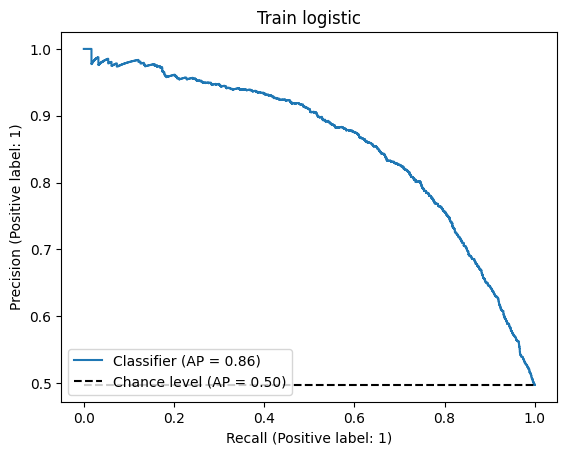

In [31]:
l, s = train['label'], positional_logit.predict()
display = PrecisionRecallDisplay.from_predictions(
    l,
    s, 
    plot_chance_level=True, pos_label=1
)
_ = display.ax_.set_title('Train logistic')
print('Average precision:', average_precision_score(l, s))

Encode test alignments in a table:

In [32]:
X_test = encode_biopython_simple(alignments_test)
X_test.index = test.index

In [33]:
X_test.drop(['0_is_mismatch', '21_is_mismatch'], axis=1, inplace=True)

In [34]:
test_pred = positional_logit.predict(exog=X_test)

Average precision: 0.8468593747458661


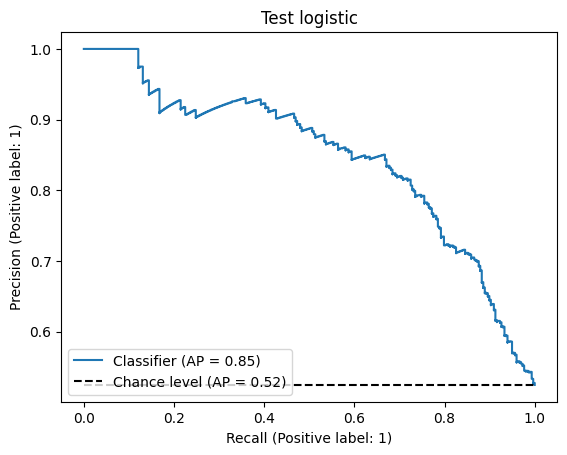

In [35]:
l, s = test['label'], positional_logit.predict(X_test)
display = PrecisionRecallDisplay.from_predictions(
    l,
    s, 
    plot_chance_level=True, pos_label=1
)
_ = display.ax_.set_title('Test logistic')
print('Average precision:', average_precision_score(l, s))

We get some increase in both train and test scores, but nothing impressive.  

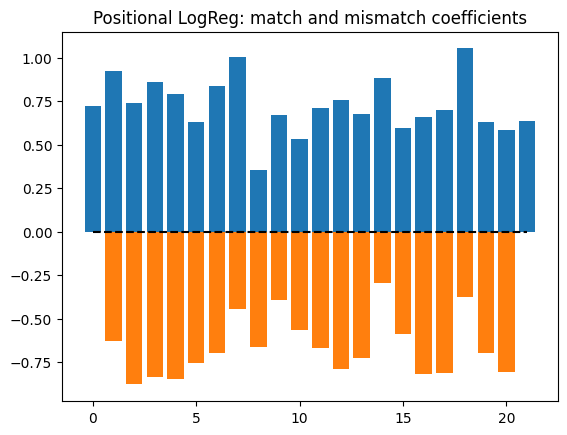

In [36]:
plt.figure()
plt.title('Positional LogReg: match and mismatch coefficients')
plt.bar(np.arange(22), positional_logit.params[match_columns])
plt.bar(np.arange(1, 21), positional_logit.params[mismatch_columns])
plt.plot([0, 21], [0, 0], 'k--')

Text(0.5, 1.0, 'Score distriution in positional LogReg')

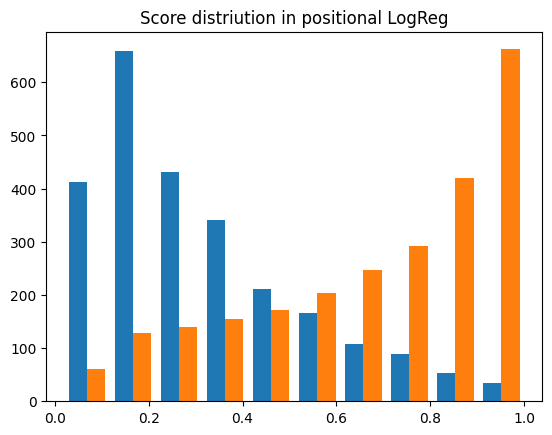

In [37]:
plt.figure()
plt.hist([positional_logit.predict()[train['label']==0], positional_logit.predict()[train['label']==1]])
plt.title('Score distriution in positional LogReg')


# Application to positional alignment
Let's see if the weights learned with logistic regression can be used to create a scoring matrix in a positionally-aware alignment

In [8]:
from src.positional_alignment import pos_aware_align_local, get_posaware_aligner_score, get_posaware_alignments
from src.logreg_analysis import get_params_from_model, encode_posloc_simple
from Bio.Seq import Seq

Baseline:

In [39]:
match_score = 5
mismatch_score = -4
gap_score = -6

In [40]:
M = np.zeros((4, 4, 22))   # third coordinate = nt index
for i in range(22):
    M[...,i] = np.eye(4)*(match_score - mismatch_score)
    M[..., i] += mismatch_score

In [41]:
G_miR = np.zeros(21) + gap_score
G_gene = np.zeros(22) + gap_score

In [42]:
print(get_posaware_aligner_score(M, G_miR, G_gene, train))

0.8455613438747726


In [43]:
print(get_posaware_aligner_score(M, G_miR, G_gene, test))

0.8351020035002059


Positional:

In [44]:
M, G_miR, G_gene = get_params_from_model(positional_logit)

In [45]:
print(get_posaware_aligner_score(M, G_miR, G_gene, train))

0.8581740852824882


In [46]:
print(get_posaware_aligner_score(M, G_miR, G_gene, test))

0.8462596586328378


We get an improvement in both scores - nice! 

Let's see if the new alignments can further improve LogReg

In [47]:
alignments_train = get_posaware_alignments(train, M, G_miR, G_gene)
alignments_test = get_posaware_alignments(test, M, G_miR, G_gene)

In [48]:
X_train = encode_posloc_simple(alignments_train)
X_train.index = train.index
X_test = encode_posloc_simple(alignments_test)
X_test.index = test.index

In [49]:
[c for c in X_train.columns if sum(X_train[c]) == 0]

['0_is_mismatch', '20_is_mismatch', '21_is_mismatch']

In [50]:
# cols_to_drop = ['0_is_mismatch', '21_is_mismatch']
cols_to_drop = ['0_is_mismatch','20_is_mismatch', '21_is_mismatch']
X_test.drop(cols_to_drop, axis=1, inplace=True)
X_train.drop(cols_to_drop, axis=1, inplace=True)

In [51]:
refitted_positional_logit_machine = Logit(endog = train['label'], exog=X_train)

In [52]:
# refitted_positional_logit=refitted_positional_logit_machine.fit_regularized(alpha=5)
refitted_positional_logit=refitted_positional_logit_machine.fit()

Optimization terminated successfully.
         Current function value: 0.477213
         Iterations 7


In [53]:
refitted_positional_logit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                  label   No. Observations:                 4980
Model:                          Logit   Df Residuals:                     4936
Method:                           MLE   Df Model:                           43
Date:                Fri, 10 Oct 2025   Pseudo R-squ.:                  0.3115
Time:                        17:04:08   Log-Likelihood:                -2376.5
converged:                       True   LL-Null:                       -3451.8
Covariance Type:            nonrobust   LLR p-value:                     0.000
==================================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
0_is_match         0.8271      0.108      7.664      0.000       0.616       1.039
1_is_match         1.0204      0.134      7.594      0.000       0.757       1.284
1_is_mismatch     -0.6823      0.257     -2.660      0.008      -1.185      -0.180
2_is_match         0.7011      0.128      5.486      0.000       0.451       0.952
2_is_mismatch     -1.1338      0.211     -5.374      0.000      -1.547      -0.720
3_is_match         0.7056      0.138      5.113      0.000       0.435       0.976
3_is_mismatch     -0.9446      0.236     -4.006      0.000      -1.407      -0.482
4_is_match         1.0241      0.122      8.364      0.000       0.784       1.264
4_is_mismatch     -0.5391      0.190     -2.844      0.004      -0.911      -0.168
5_is_match         0.6289      0.110      5.734      0.000       0.414       0.844
5_is_mismatch     -0.9014      0.153     -5.873      0.000      -1.202      -0.601
6_is_match         0.9619      0.120      8.013      0.000       0.727       1.197
6_is_mismatch     -0.6554      0.166     -3.942      0.000      -0.981      -0.330
7_is_match         0.9950      0.149      6.697      0.000       0.704       1.286
7_is_mismatch     -0.5738      0.184     -3.120      0.002      -0.934      -0.213
8_is_match         0.2495      0.103      2.412      0.016       0.047       0.452
8_is_mismatch     -0.8592      0.127     -6.764      0.000      -1.108      -0.610
9_is_match         0.8386      0.138      6.067      0.000       0.568       1.110
9_is_mismatch     -0.3251      0.157     -2.073      0.038      -0.632      -0.018
10_is_match        0.6182      0.115      5.389      0.000       0.393       0.843
10_is_mismatch    -0.4564      0.138     -3.313      0.001      -0.726      -0.186
11_is_match        0.7914      0.118      6.693      0.000       0.560       1.023
11_is_mismatch    -0.7238      0.159     -4.541      0.000      -1.036      -0.411
12_is_match        0.5280      0.121      4.354      0.000       0.290       0.766
12_is_mismatch    -1.3192      0.180     -7.320      0.000      -1.672      -0.966
13_is_match        0.7807      0.112      6.958      0.000       0.561       1.001
13_is_mismatch    -0.8447      0.155     -5.449      0.000      -1.149      -0.541
14_is_match        0.8887      0.143      6.228      0.000       0.609       1.168
14_is_mismatch    -0.3803      0.168     -2.265      0.024      -0.709      -0.051
15_is_match        0.5818      0.114      5.085      0.000       0.358       0.806
15_is_mismatch    -0.6415      0.143     -4.495      0.000      -0.921      -0.362
16_is_match        0.7541      0.123      6.155      0.000       0.514       0.994
16_is_mismatch    -0.9407      0.194     -4.851      0.000      -1.321      -0.561
17_is_match        0.9122      0.148      6.154      0.000       0.622       1.203
17_is_mismatch    -0.7377      0.208     -3.542      0.000      -1.146      -0.329
18_is_match        1.0941      0.165      6.635      0.000       0.771       1.417
18_i

Average precision: 0.8609432092097412


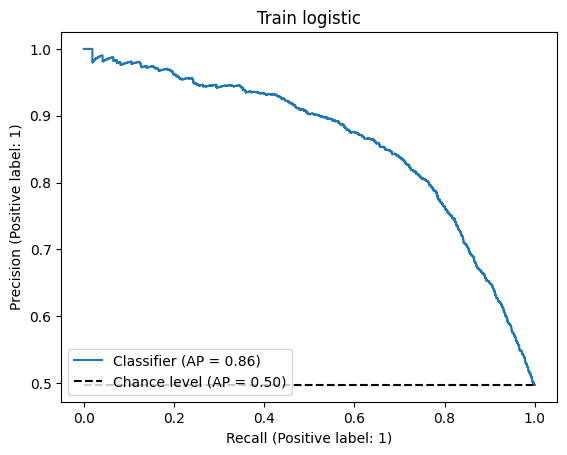

In [54]:
l, s = train['label'], refitted_positional_logit.predict()
display = PrecisionRecallDisplay.from_predictions(
    l,
    s, 
    plot_chance_level=True, pos_label=1
)
_ = display.ax_.set_title('Train logistic')
print('Average precision:', average_precision_score(l, s))

Average precision: 0.8500308553215947


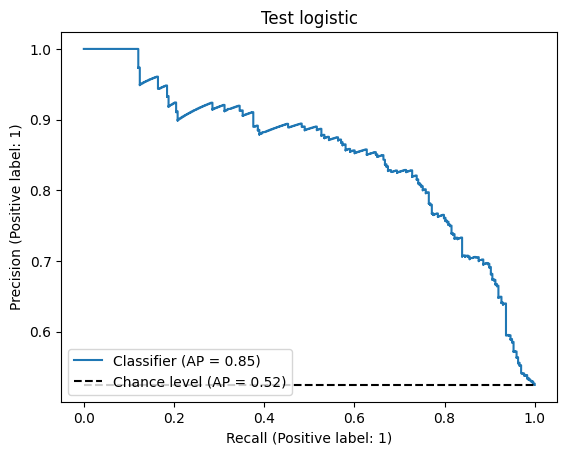

In [55]:
l, s = test['label'], refitted_positional_logit.predict(X_test)
display = PrecisionRecallDisplay.from_predictions(
    l,
    s, 
    plot_chance_level=True, pos_label=1
)
_ = display.ax_.set_title('Test logistic')
print('Average precision:', average_precision_score(l, s))

For some crazy reason it actually works! 

Naive refitting:

In [98]:
# M = np.zeros((4, 4, 22))   # third coordinate = nt index
# for i in range(22):
#     M[...,i] = np.eye(4)*(match_score - mismatch_score)
#     M[..., i] += mismatch_score
# G_miR = np.zeros(21) + gap_score
# G_gene = np.zeros(22) + gap_score  
    
# train_scores_logistic = []
# train_scores_aligner = [get_posaware_aligner_score(M, G_miR, G_gene, train)]
# test_scores_logistic = []
# test_scores_aligner = [get_posaware_aligner_score(M, G_miR, G_gene, test)]
# for iter_nb in range(15):
#     print('Iter', iter_nb+1)
#     alignments_train = get_posaware_alignments(train, M, G_miR, G_gene)
#     X_train = encode_posloc_simple(alignments_train)
#     X_train.index = train.index
#     # for test score monitoring - optional
#     alignments_test = get_posaware_alignments(test, M, G_miR, G_gene)
#     X_test = encode_posloc_simple(alignments_test)
#     X_test.index = test.index
    
#     print([c for c in X_train.columns if sum(X_train[c]) == 0])
#     cols_to_drop = ['0_is_mismatch', '21_is_mismatch']
#     cols_to_drop += [c for c in X_train.columns if sum(X_train[c]) == 0]
#     X_test.drop(cols_to_drop, axis=1, inplace=True)
#     X_train.drop(cols_to_drop, axis=1, inplace=True)
    
#     refitted_positional_logit_machine = Logit(endog = train['label'], exog=X_train)
#     # refitted_positional_logit = refitted_positional_logit_machine.fit_regularized(alpha=1)
#     refitted_positional_logit = refitted_positional_logit_machine.fit()
    
#     # test scores
#     l, s = train['label'], refitted_positional_logit.predict()
#     train_scores_logistic.append(average_precision_score(l, s))
#     l, s = test['label'], refitted_positional_logit.predict(X_test)
#     test_scores_logistic.append(average_precision_score(l, s))
    
#     # Parameter update
#     M, G_miR, G_gene = get_params_from_model(refitted_positional_logit)
#     # train_scores_aligner.append(get_posaware_aligner_score(M, G_miR, G_gene, train))
#     # test_scores_aligner.append(get_posaware_aligner_score(M, G_miR, G_gene, test))